In [1]:
import joblib
from pathlib import Path
import pandas as pd

from ml_baselines.data import read_agage, read_intem
from ml_baselines.features import open_features
from ml_baselines.config import Config

cfg = Config()

In [2]:
site = "MHD"
species = "hfc-134a"
start_year=2010
end_year=2020

df_agage = read_agage(site, species, start_year=start_year, end_year=end_year)
df_intem = read_intem(site, start_year=start_year, end_year=end_year)

In [3]:
# Ensure both DataFrames have their index as a sorted datetime index
df_agage = df_agage.sort_index()
df_intem = df_intem.sort_index()

# Merge using merge_asof. Assuming the column you want to bring in is 'baseline'
df_merged = pd.merge_asof(
    df_agage,
    df_intem[['baseline']],   # extract only the baseline column
    left_index=True,
    right_index=True,
    direction='nearest'        # use 'nearest' to match to the closest timestamp
)

<Axes: xlabel='time'>

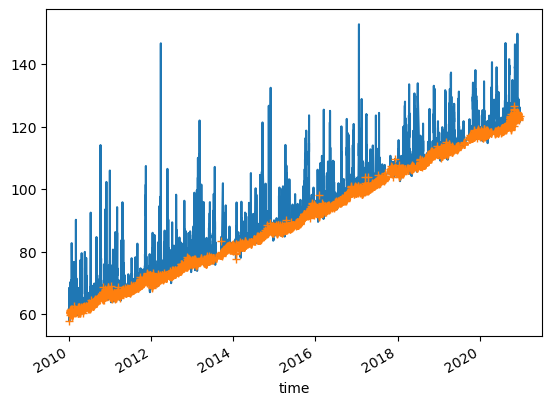

In [4]:
# Plot only baseline values
df_merged["mf"].plot(label='AGAGE')
df_merged["mf"][df_merged["baseline"] == 1].plot(style='+', label='InTEM')


In [5]:
df_features = open_features(site,
                            start_year=df_agage.index.year.min(),
                            end_year=df_agage.index.year.max()).sort_index()

In [6]:
nearest_positions = df_features.index.get_indexer(df_merged.index, method='nearest')

# Extract the corresponding rows from df_features
df_features_nearest = df_features.iloc[nearest_positions]
df_features_nearest.index = df_merged.index.copy()

In [11]:
# Load model
met_str = f"-{cfg.met_type}" if cfg.met_type else ""
model = joblib.load(Path(cfg.models_path) / f"mlp{met_str}_{site}.joblib")

In [12]:
# Drop any nan rows (when we don't have -6h data) and record which indices have been dropped
dropped_indices = df_features_nearest[df_features_nearest.isna().any(axis=1)].index
# Predict
predictions = model.predict(df_features_nearest.dropna())

In [13]:
df_merged_dropped = df_merged.loc[~df_merged.index.isin(dropped_indices)]
df_merged_dropped.loc[:, "baseline"] = predictions

<Axes: xlabel='time'>

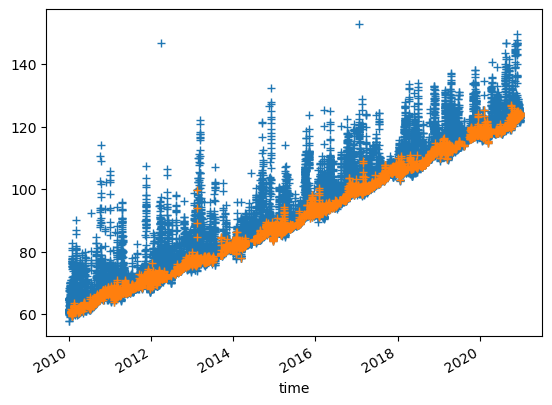

In [14]:
df_merged_dropped.mf.plot(marker="+", linewidth=0)
df_merged_dropped.mf[df_merged_dropped.baseline == 1].plot(marker = "+", linewidth=0)